## Entrenamiento del modelo

## 1.1 Importacion de los datos y las librerias necesarias

In [17]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelo
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

### Importo el CSV Data as Pandas DataFrame

In [18]:
df = pd.read_csv('data/stud.csv')

In [19]:
df = df.rename(columns={
    "gender": "genero",
    "race_ethnicity": "grupo_etnico",
    "parental_level_of_education": "nivel_educacion_padres",
    "lunch": "almuerzo",
    "test_preparation_course": "curso_preparacion",
    "math_score": "nota_matematica",
    "reading_score": "nota_lectura",
    "writing_score": "nota_escritura"
})

# genero
df["genero"] = df["genero"].map({
    "female": "femenino",
    "male": "masculino"
})

# grupo étnico (opcional, podés dejarlo igual si querés)
df["grupo_etnico"] = df["grupo_etnico"].str.replace("group ", "grupo ")

# nivel educación padres
df["nivel_educacion_padres"] = df["nivel_educacion_padres"].map({
    "bachelor's degree": "licenciatura",
    "master's degree": "maestria",
    "associate's degree": "tecnicatura",
    "some college": "algo de universidad",
    "high school": "secundaria",
    "some high school": "secundaria incompleta"
})

# almuerzo
df["almuerzo"] = df["almuerzo"].map({
    "standard": "estandar",
    "free/reduced": "gratuito/reducido"
})

# curso preparación
df["curso_preparacion"] = df["curso_preparacion"].map({
    "none": "ninguno",
    "completed": "completado"
})

### Mostrar los 5 mejores récords

In [20]:
df.head(5)

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_matematica,nota_lectura,nota_escritura
0,femenino,grupo B,licenciatura,estandar,ninguno,72,72,74
1,femenino,grupo C,algo de universidad,estandar,completado,69,90,88
2,femenino,grupo B,maestria,estandar,ninguno,90,95,93
3,masculino,grupo A,tecnicatura,gratuito/reducido,ninguno,47,57,44
4,masculino,grupo C,algo de universidad,estandar,ninguno,76,78,75


### Preparación de las variables X e Y

In [21]:
X = df.drop(columns=['nota_matematica'], axis = 1)

In [22]:
X.head()

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_lectura,nota_escritura
0,femenino,grupo B,licenciatura,estandar,ninguno,72,74
1,femenino,grupo C,algo de universidad,estandar,completado,90,88
2,femenino,grupo B,maestria,estandar,ninguno,95,93
3,masculino,grupo A,tecnicatura,gratuito/reducido,ninguno,57,44
4,masculino,grupo C,algo de universidad,estandar,ninguno,78,75


In [23]:
print('Categorias en la variable "genero":', end=" " )
print(df['genero'].unique())

print('Categorias en la variable "grupo etnico":', end="")
print(df['grupo_etnico'].unique())

print('Categorias en la variable "Nivel de educacion de los padres":', end="")
print(df['nivel_educacion_padres'].unique())

print('Categorias en la variable "almuerzo":', end="")
print(df['almuerzo'].unique())

print('Categorias en la variable "Curso de preparacion":', end="")
print(df['curso_preparacion'].unique())

Categorias en la variable "genero": ['femenino' 'masculino']
Categorias en la variable "grupo etnico":['grupo B' 'grupo C' 'grupo A' 'grupo D' 'grupo E']
Categorias en la variable "Nivel de educacion de los padres":['licenciatura' 'algo de universidad' 'maestria' 'tecnicatura'
 'secundaria' 'secundaria incompleta']
Categorias en la variable "almuerzo":['estandar' 'gratuito/reducido']
Categorias en la variable "Curso de preparacion":['ninguno' 'completado']


In [24]:
y = df['nota_matematica']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: nota_matematica, Length: 1000, dtype: int64

In [25]:
# Crear un transformador de columna con 3 tipos de transformadores
caracteristica_num = X.select_dtypes(exclude='object').columns
caracteristica_categorica = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

transformacion_numerica = StandardScaler()
oh_transformacion = OneHotEncoder()

procesador = ColumnTransformer(
    [
        ('codificador_onehot', oh_transformacion, caracteristica_categorica),
        ('transformacion_numerica', transformacion_numerica, caracteristica_num)
    ]
)

In [26]:
X = procesador.fit_transform(X)

In [27]:
X.shape

(1000, 19)

In [28]:
# separar el conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Crear una función de evaluación para proporcionar todas las métricas despúes del entrenamiento del modelo.

In [38]:
def evaluar_modelo(true, predict):
    mae = mean_absolute_error(true, predict)
    mse = mean_squared_error(true, predict)
    rmse = np.sqrt(mean_squared_error(true, predict))
    r2 = r2_score(true, predict)

    return mae, rmse, r2

In [39]:
modelo = {
    'Regresion lineal': LinearRegression(),
    'Lazo': Lasso(),
    'Ridge': Ridge(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor(),
    'CatBoosting Regressor': CatBoostRegressor(verbose=False),
    'AndaBost Regressor': AdaBoostRegressor()
}

lista_modelo = []
r2_list = []

for nombre, model in modelo.items():
    # Entrenamiento del modelo
    model.fit(X_train, y_train)

    # Predicciones 
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluación 
    model_train_mae, model_train_rmse, model_train_r2 = evaluar_modelo(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluar_modelo(y_test, y_test_pred)

    # Guardar resultados
    lista_modelo.append(nombre)
    r2_list.append(model_test_r2)

    # Reporte
    print(f"Modelo: {nombre}")
    print('Rendimiento para el conjunto de TEST:')
    print(f' - MAE: {model_test_mae:.2f}')
    print(f' - RMSE: {model_test_rmse:.2f}')
    print(f' - R2 Score: {model_test_r2:.2f}')
    print('='*35 + '\n')

Modelo: Regresion lineal
Rendimiento para el conjunto de TEST:
 - MAE: 4.21
 - RMSE: 5.39
 - R2 Score: 0.88

Modelo: Lazo
Rendimiento para el conjunto de TEST:
 - MAE: 5.16
 - RMSE: 6.52
 - R2 Score: 0.83

Modelo: Ridge
Rendimiento para el conjunto de TEST:
 - MAE: 4.21
 - RMSE: 5.39
 - R2 Score: 0.88

Modelo: K-Neighbors Regressor
Rendimiento para el conjunto de TEST:
 - MAE: 5.64
 - RMSE: 7.26
 - R2 Score: 0.78

Modelo: Decision Tree
Rendimiento para el conjunto de TEST:
 - MAE: 6.09
 - RMSE: 7.76
 - R2 Score: 0.75

Modelo: Random Forest Regressor
Rendimiento para el conjunto de TEST:
 - MAE: 4.64
 - RMSE: 6.03
 - R2 Score: 0.85

Modelo: XGBRegressor
Rendimiento para el conjunto de TEST:
 - MAE: 5.07
 - RMSE: 6.46
 - R2 Score: 0.83

Modelo: CatBoosting Regressor
Rendimiento para el conjunto de TEST:
 - MAE: 4.62
 - RMSE: 6.05
 - R2 Score: 0.85

Modelo: AndaBost Regressor
Rendimiento para el conjunto de TEST:
 - MAE: 4.70
 - RMSE: 6.04
 - R2 Score: 0.85



### Resultados

In [40]:
pd.DataFrame(list(zip(lista_modelo, r2_list)), columns=['Nombre del modelo', 'R2_Score']).sort_values(by=['R2_Score'], ascending= False)

,Nombre del modelo,R2_Score
2,Ridge,0.880593
0,Regresion lineal,0.880433
5,Random Forest Regressor,0.850558
8,AndaBost Regressor,0.850193
7,CatBoosting Regressor,0.849538
6,XGBRegressor,0.828383
1,Lazo,0.825320
3,K-Neighbors Regressor,0.783497
4,Decision Tree,0.752834


### Regresion Lineal

In [41]:
modelo_lin = LinearRegression(fit_intercept=True)
modelo_lin = modelo_lin.fit(X_train, y_train)
y_pred = modelo_lin.predict(X_test)
score = r2_score(y_test, y_pred)*100
print('La precisión del modelo es %.2f'%score)

La precisión del modelo es 88.04


### Grafica y_pred, t_test

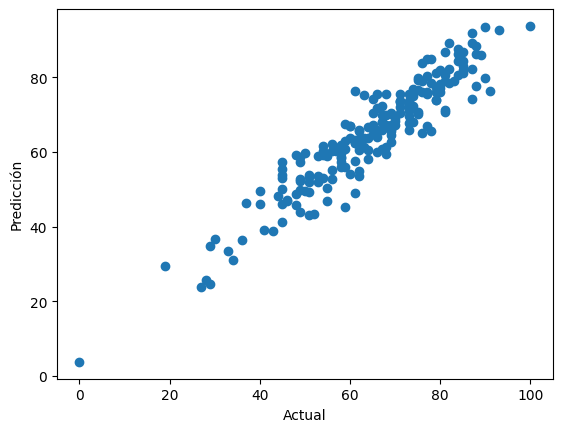

In [42]:
plt.scatter(y_test, y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicción')
plt.show()

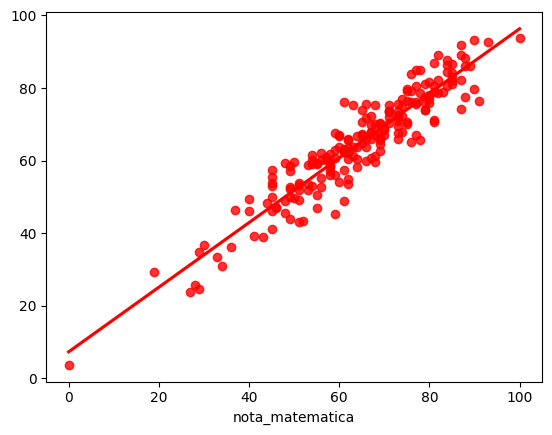

In [44]:
sns.regplot(x = y_test, y= y_pred, ci=None, color='red')
plt.show()

### Diferencia entre valores reales y valores previstos

In [46]:
pred_df = pd.DataFrame({
        'Valor Actual:': y_test,
        'Valor Predecido:' : y_pred,
        'Diferencia:' : y_test - y_pred
    })

pred_df

,Valor Actual:,Valor Predecido:,Diferencia:
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
